# Analisis Dataset


In [ ]:
!pip install pillow-heif
!pip install opencv-python

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pillow_heif
import shutil

ModuleNotFoundError: No module named 'pillow_heif'

### TAHAP 1: DATA CLEANING & PREPROCESSING (Hanya untuk Dataset Tambahan)

In [ ]:
pillow_heif.register_heif_opener()

sns.set_theme(style="whitegrid")

def clean_and_convert_heic_to_jpg(input_folder, output_folder):
    """
    Fungsi yang diperbarui:
    - Mengonversi file HEIC menjadi JPG.
    - Menyalin langsung file yang sudah berformat JPG/JPEG/PNG ke folder tujuan.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    print("===== Memulai Proses Data Cleaning & Sinkronisasi Folder =====")

    for class_name in os.listdir(input_folder):
        input_class_path = os.path.join(input_folder, class_name)

        if os.path.isdir(input_class_path):
            output_class_path = os.path.join(output_folder, class_name)
            if not os.path.exists(output_class_path):
                os.makedirs(output_class_path)

            all_files = os.listdir(input_class_path)

            count_heic = 0
            count_copied = 0

            for filename in all_files:
                file_path = os.path.join(input_class_path, filename)
                ext = filename.lower()

                if ext.endswith(('.heic', '.heif')):
                    jpg_filename = os.path.splitext(filename)[0] + ".jpg"
                    jpg_path = os.path.join(output_class_path, jpg_filename)

                    try:
                        with Image.open(file_path) as img:
                            rgb_img = img.convert('RGB')
                            rgb_img.save(jpg_path, 'JPEG', quality=95)
                        count_heic += 1
                    except Exception as e:
                        print(f"  ❌ Gagal konversi {filename} di kelas {class_name}: {e}")

                elif ext.endswith(('.jpg', '.jpeg', '.png')):
                    destination_path = os.path.join(output_class_path, filename)
                    try:
                        shutil.copy2(file_path, destination_path)
                        count_copied += 1
                    except Exception as e:
                        print(f"  ❌ Gagal menyalin {filename} di kelas {class_name}: {e}")

            if count_heic > 0 or count_copied > 0:
                print(f"Kelas [{class_name}]: Berhasil mengonversi {count_heic} HEIC & menyalin {count_copied} gambar standar.")

    print("===== Data Cleaning Selesai! Seluruh data tambahan kini utuh di folder bersih =====\n")

### TAHAP 2: EKSTRAKSI KARAKTERISTIK DATASET (EDA)

In [ ]:
def analyze_dataset_folder(root_path, dataset_label):
    """
    Fungsi untuk mengekstrak metadata dari folder dataset citra yang sudah bersih (berformat JPG/PNG).
    """
    data_list = []

    if not os.path.exists(root_path):
        print(f"Peringatan: Path {root_path} tidak ditemukan.")
        return pd.DataFrame(data_list)

    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)

        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode

                    data_list.append({
                        'Dataset': dataset_label,
                        'Kelas': class_name,
                        'Nama_File': img_name,
                        'Width': width,
                        'Height': height,
                        'Channels': 3 if mode == 'RGB' else (1 if mode == 'L' else 0),
                        'Aspect_Ratio': round(width / height, 2)
                    })
                except Exception as e:
                    print(f"Gagal membaca {img_path}: {e}")

    return pd.DataFrame(data_list)

In [ ]:
PATH_KAGGLE = "./Dataset_Rupiah_Emisi-2016(Kaggle)"
PATH_TAMBAHAN_MENTAH = "./Dataset Tambahan"
PATH_TAMBAHAN_BERSIH = "./Dataset-Tambahan-Bersih"

clean_and_convert_heic_to_jpg(PATH_TAMBAHAN_MENTAH, PATH_TAMBAHAN_BERSIH)

df_kaggle = analyze_dataset_folder(PATH_KAGGLE, "Kaggle (Utama)")
df_tambahan = analyze_dataset_folder(PATH_TAMBAHAN_BERSIH, "Tambahan (Bersih)")

df_all = pd.concat([df_kaggle, df_tambahan], ignore_index=True)
print(f"Total gambar gabungan yang siap dimodelkan: {len(df_all)} file.\n")

===== Memulai Proses Data Cleaning & Sinkronisasi Folder =====
Kelas [1000]: Berhasil mengonversi 9 HEIC & menyalin 42 gambar standar.
Kelas [10000]: Berhasil mengonversi 7 HEIC & menyalin 42 gambar standar.
Kelas [100000]: Berhasil mengonversi 7 HEIC & menyalin 42 gambar standar.
Kelas [2000]: Berhasil mengonversi 8 HEIC & menyalin 42 gambar standar.
Kelas [20000]: Berhasil mengonversi 30 HEIC & menyalin 12 gambar standar.
Kelas [5000]: Berhasil mengonversi 19 HEIC & menyalin 34 gambar standar.
Kelas [50000]: Berhasil mengonversi 11 HEIC & menyalin 44 gambar standar.
Kelas [Bukan Uang]: Berhasil mengonversi 115 HEIC & menyalin 311 gambar standar.
===== Data Cleaning Selesai! Seluruh data tambahan kini utuh di folder bersih =====

Total gambar gabungan yang siap dimodelkan: 3173 file.



### TAHAP 3: VISUALISASI HASIL ANALISIS DATA (REPORTING)

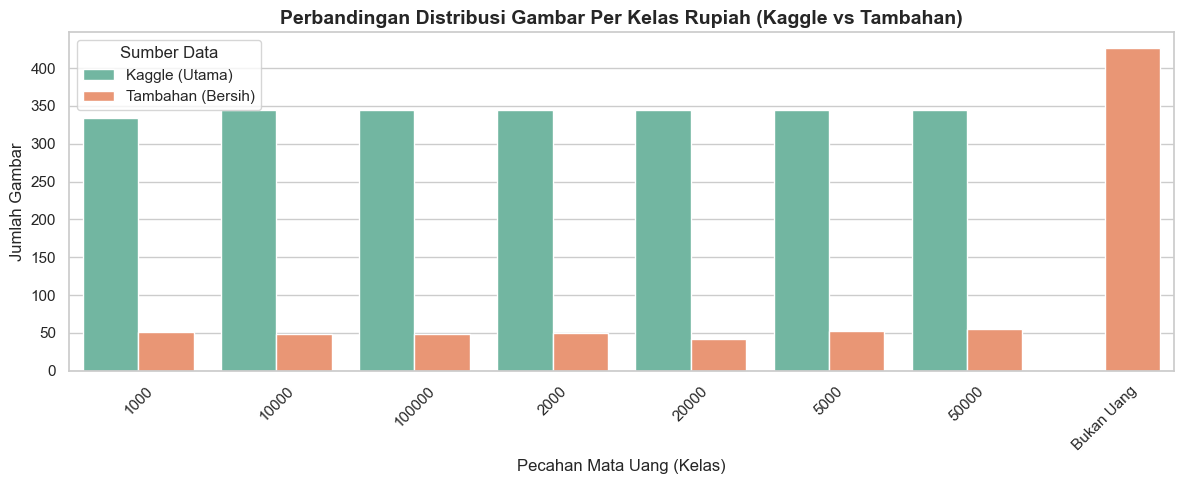

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_all, x='Kelas', hue='Dataset', palette='Set2',
              order=sorted(df_all['Kelas'].unique()))
plt.title('Perbandingan Distribusi Gambar Per Kelas Rupiah (Kaggle vs Tambahan)', fontsize=14, fontweight='bold')
plt.xlabel('Pecahan Mata Uang (Kelas)')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.legend(title='Sumber Data')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3396\3295252850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_all, x='Dataset', y='Aspect_Ratio', palette='Pastel1')


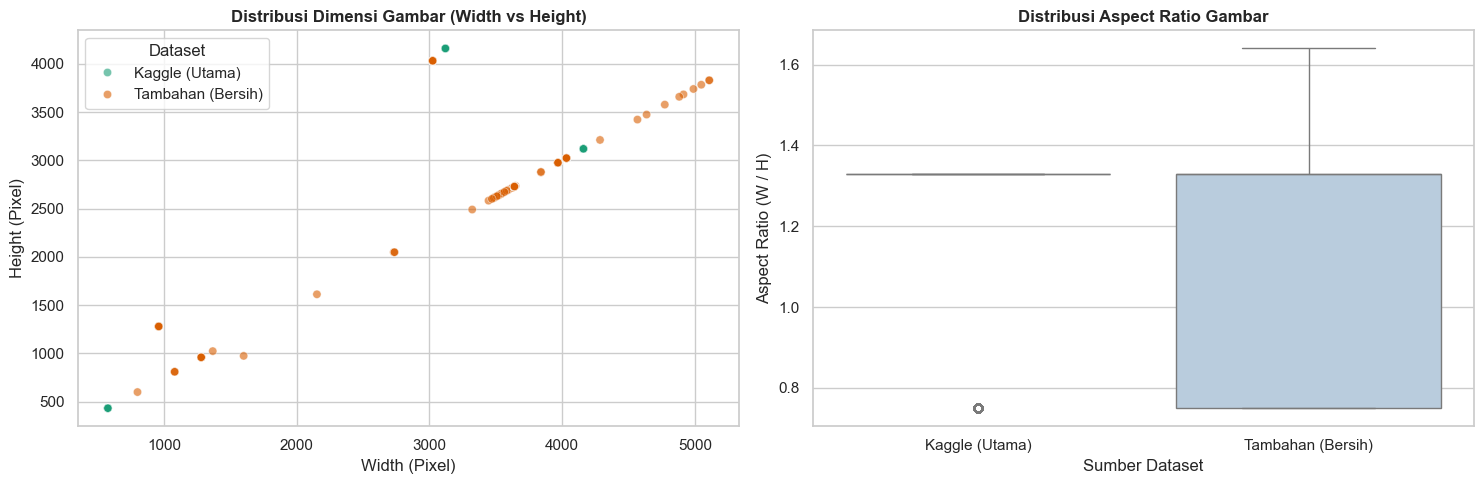

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(ax=axes[0], data=df_all, x='Width', y='Height', hue='Dataset', alpha=0.6, palette='Dark2')
axes[0].set_title('Distribusi Dimensi Gambar (Width vs Height)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (Pixel)')
axes[0].set_ylabel('Height (Pixel)')

sns.boxplot(ax=axes[1], data=df_all, x='Dataset', y='Aspect_Ratio', palette='Pastel1')
axes[1].set_title('Distribusi Aspect Ratio Gambar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sumber Dataset')
axes[1].set_ylabel('Aspect Ratio (W / H)')
plt.tight_layout()
plt.show()

In [ ]:
print("--- Rangkuman Statistik Dataset Gabungan ---")
print(pd.crosstab(df_all['Kelas'], df_all['Dataset'], margins=True))

--- Rangkuman Statistik Dataset Gabungan ---
Dataset     Kaggle (Utama)  Tambahan (Bersih)   All
Kelas                                              
1000                   334                 51   385
10000                  344                 49   393
100000                 344                 49   393
2000                   344                 50   394
20000                  344                 42   386
5000                   344                 53   397
50000                  344                 55   399
Bukan Uang               0                426   426
All                   2398                775  3173


In [ ]:
print("--- Analisis Karakteristik Dimensi Gambar ---")
dimensi_summary = df_all.groupby('Dataset')[['Width', 'Height', 'Aspect_Ratio']].agg(['min', 'max', 'mean', 'median'])
display(dimensi_summary)

print("\n--- Analisis Kecenderungan Orientasi Gambar ---")
# Aspect Ratio > 1 artinya Landscape, < 1 artinya Portrait, == 1 artinya Square
df_all['Orientasi'] = np.where(df_all['Aspect_Ratio'] > 1.05, 'Landscape',
                               np.where(df_all['Aspect_Ratio'] < 0.95, 'Portrait', 'Square'))

orientasi_summary = pd.crosstab(df_all['Orientasi'], df_all['Dataset'], normalize='columns') * 100
print(orientasi_summary.round(2).astype(str) + '%')

--- Analisis Karakteristik Dimensi Gambar ---


Width                            Height                     \
                    min   max         mean  median    min   max         mean   
Dataset                                                                        
Kaggle (Utama)      577  4160  1334.907840   577.0    433  4160  1246.514178   
Tambahan (Bersih)   800  5108  3298.054194  3968.0    600  4032  2904.305806   

                          Aspect_Ratio                         
                   median          min   max      mean median  
Dataset                                                        
Kaggle (Utama)      433.0         0.75  1.33  1.251877   1.33  
Tambahan (Bersih)  2976.0         0.75  1.64  1.138103   1.33


--- Analisis Kecenderungan Orientasi Gambar ---
Dataset   Kaggle (Utama) Tambahan (Bersih)
Orientasi                                 
Landscape         86.53%            66.84%
Portrait          13.47%            33.16%


### 📄 LAPORAN AKHIR RISET & ANALISIS DATASET GABUNGAN

Berikut adalah hasil analisis karakteristik data final dan rekomendasi teknis sebelum lanjut ke tahap berikutnya:

---

#### 1. Rangkuman Kuantitas & Distribusi Data Terbaru
Saat ini, total data bersih siap pakai kita melonjak menjadi **3.173 gambar** (gabungan Kaggle dan dataset tambahan), dengan rincian distribusi sebagai berikut:
* **Dataset Utama (Kaggle):** Total **2.398 gambar**. Distribusinya sangat seimbang (*perfectly balanced*) di angka 334–344 gambar per kelas nominal pecahan (Emisi 2016).
* **Dataset Tambahan (Foto HP Tim):** Total **775 gambar**.

---

#### 2. Analisis Karakteristik Dimensi & Orientasi Citra
Hasil ekstraksi visual menunjukkan adanya *gap* karakteristik geometris yang tetap harus kita mitigasi:
* **Dataset Kaggle:** Dominan berbentuk kotak (*Square*) atau persegi panjang horizontal (**Landscape**) dengan resolusi piksel kecil yang seragam.
* **Dataset Tambahan:** Dominan berbentuk tegak vertikal (**Portrait**) dengan resolusi piksel asli yang sangat tinggi (khas jepretan kamera *smartphone*).

---

### 🛠️ REKOMENDASI TEKNIS & PIPELINE PREPROCESSING

1. **Gunakan Teknik Resize with Padding / Letterboxing (Krusial):**
Mohon jangan langsung menggunakan fungsi `transforms.Resize((224, 224))` biasa. Karena 451 data tambahan kita dominan berbentuk **Portrait** sedangkan 2.398 data Kaggle berbentuk **Landscape**, *direct resize* akan memaksa gambar tegak ditarik melebar secara horizontal. Hal ini membuat fisik uang kertas terdistorsi (gepeng) dan merusak visual pola pahlawan/nominal uang yang harus dipelajari model.
* *Solusi:* Terapkan fungsi *padding* (tepian hitam/putih) untuk mempertahankan aspek rasio asli uang, baru skalanya dikecilkan ke ukuran input model.
2. **Standardisasi Skala Piksel (*Feature Scaling*):**
Mengingat adanya lonjakan resolusi piksel yang sangat jauh antara foto HP (sangat besar) dan dataset Kaggle (kecil), pastikan fungsi normalisasi nilai piksel ke rentang `0-1` (`transforms.ToTensor()` atau membagi matriks dengan 255.0) diaplikasikan secara merata di kedua sumber data untuk menjaga stabilitas konvergensi bobot model.
3. **Optimalisasi Augmentasi Data (*Data Augmentation*):**
Meskipun data tambahan kita sudah aman, rasionya masih lebih kecil dibanding dataset Kaggle. Oleh karena itu, ML Engineer wajib memperkuat augmentasi acak pada *training pipeline*, khususnya: **Rotasi Acak (*Random Rotation*)**, **Pergeseran Jendela (*Width/Height Shift*)**, dan **Manipulasi Pencahayaan (*Brightness/Contrast Adjustment*)**. Ini sangat penting karena kondisi pengambilan gambar nyata oleh pengunjung di area museum akan sangat bervariasi sudut dan intensitas cahayanya.

---

Folder dataset tambahan yang sudah melalui proses penyelarasan dan bersih berformat JPG (`Dataset-Tambahan-Bersih`) sudah siap digunakan untuk tahap selanjutnya (Preprocessing + Modeling).

# Import Library

In [ ]:
!pip install pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 114.2 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import torch
import json
import torch.nn as nn
import matplotlib.pyplot as plt
import onnx
import seaborn as sns
from google.colab import drive, files
from pathlib import Path
from splitfolders import ratio
from PIL import Image
from pillow_heif import register_heif_opener
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Data Preparation

## Dataset

Dataset tambahan drive

In [ ]:

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Dataset-Tambahan-Bersih"

In [ ]:
for kelas in sorted(os.listdir(path)):
  kelas_path = os.path.join(path, kelas)

  if os.path.isdir(kelas_path):
    jumlah = len([
        f for f in os.listdir(kelas_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

  print(f"{kelas}: {jumlah}")

1000: 51
10000: 49
100000: 49
2000: 50
20000: 42
5000: 53
50000: 55
Bukan Uang: 426


Dataset Utama Rupiah Banknotes dari Kaggle : https://www.kaggle.com/datasets/anidwiastuti/rupiah-banknotes-dataset

In [ ]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rendiagussucipto","key":"507b77350377a83e37afb2ee2c153440"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d anidwiastuti/rupiah-banknotes-dataset

Dataset URL: https://www.kaggle.com/datasets/anidwiastuti/rupiah-banknotes-dataset
License(s): unknown
100% 2.33G/2.33G [00:19<00:00, 129MB/s] 



In [ ]:
!unzip -q rupiah-banknotes-dataset.zip -d kaggle_dataset

In [ ]:
!find kaggle_dataset -type d | head -20

kaggle_dataset
kaggle_dataset/dataset
kaggle_dataset/dataset/50000
kaggle_dataset/dataset/5000
kaggle_dataset/dataset/2000
kaggle_dataset/dataset/100000
kaggle_dataset/dataset/10000
kaggle_dataset/dataset/1000
kaggle_dataset/dataset/20000


In [ ]:
# Menggabungkan kedua dataset

#Path sumber
KAGGLE_PATH = Path("/content/kaggle_dataset/dataset")
TAMBAHAN_PATH = Path("/content/drive/MyDrive/Dataset-Tambahan-Bersih")

#Dataset final
FINAL_PATH = Path("/content/final_dataset")
FINAL_PATH.mkdir(exist_ok=True)

# Menggabungkan kelas uang
kelas_uang = ["1000", "2000", "5000", '10000', "20000", "50000", "100000"]

for kelas in kelas_uang:
  target = FINAL_PATH / kelas
  target.mkdir(exist_ok=True)

  for img in (KAGGLE_PATH / kelas).glob("*"):
    shutil.copy2(img, target)

  for img in (TAMBAHAN_PATH / kelas).glob("*"):
    shutil.copy2(img, target)

shutil.copytree(
    TAMBAHAN_PATH / "Bukan Uang",
    FINAL_PATH / "Bukan_Uang",
    dirs_exist_ok=True
)

print("Dataset gabungan berhasil dibuat")

Dataset gabungan berhasil dibuat


In [ ]:
for folder in sorted(FINAL_PATH.iterdir()):
  if folder.is_dir():
    print(folder.name, len(list(folder.glob("*"))))

1000 385
10000 393
100000 393
2000 394
20000 386
5000 397
50000 399
Bukan_Uang 426


In [ ]:
shutil.copytree(
    "/content/final_dataset",
    "/content/drive/MyDrive/final_dataset",
    dirs_exist_ok=True
)

print("Dataset berhasil disimpan ke Google Drive")

Dataset berhasil disimpan ke Google Drive


## Split Data

Training : 70%

Validation : 15%

Testing : 15%

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/final_dataset"

for kelas in sorted(os.listdir(DATASET_PATH)):
    jumlah = len(os.listdir(os.path.join(DATASET_PATH, kelas)))
    print(f"{kelas}: {jumlah}")

1000: 385
10000: 393
100000: 393
2000: 394
20000: 386
5000: 397
50000: 399
Bukan_Uang: 426


In [ ]:
ratio(
    input=DATASET_PATH,
    output="/content/drive/MyDrive/split_dataset",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 3173 files [17:43,  2.98 files/s]


In [ ]:
base = "/content/drive/MyDrive/split_dataset"

for split in ["train", "val", "test"]:
    print(f"\n=== {split.upper()} ===")

    split_path = os.path.join(base, split)

    total = 0
    for kelas in sorted(os.listdir(split_path)):
        jumlah = len(os.listdir(os.path.join(split_path, kelas)))
        total += jumlah
        print(f"{kelas}: {jumlah}")

    print(f"TOTAL {split}: {total}")


=== TRAIN ===
1000: 269
10000: 275
100000: 275
2000: 275
20000: 270
5000: 277
50000: 279
Bukan_Uang: 298
TOTAL train: 2218

=== VAL ===
1000: 57
10000: 58
100000: 58
2000: 59
20000: 57
5000: 59
50000: 59
Bukan_Uang: 63
TOTAL val: 470

=== TEST ===
1000: 59
10000: 60
100000: 60
2000: 60
20000: 59
5000: 61
50000: 61
Bukan_Uang: 65
TOTAL test: 485


## Data Loader

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/split_dataset/train"
VAL_DIR   = "/content/drive/MyDrive/split_dataset/val"
TEST_DIR  = "/content/drive/MyDrive/split_dataset/test"

class Letterbox:
    def __init__(self, size=(224, 224), fill=(0, 0, 0)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        target_w, target_h = self.size
        w, h = img.size
        scale = min(target_w / w, target_h / h)

        new_w = int(w * scale)
        new_h = int(h * scale)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        canvas = Image.new("RGB", self.size, self.fill)

        paste_x = (target_w - new_w) // 2
        paste_y = (target_h - new_h) // 2
        canvas.paste(img, (paste_x, paste_y))

        return canvas

train_transform = transforms.Compose([
    Letterbox((224, 224)),
    transforms.RandomRotation(degrees=15, fill=(0,0,0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    Letterbox((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

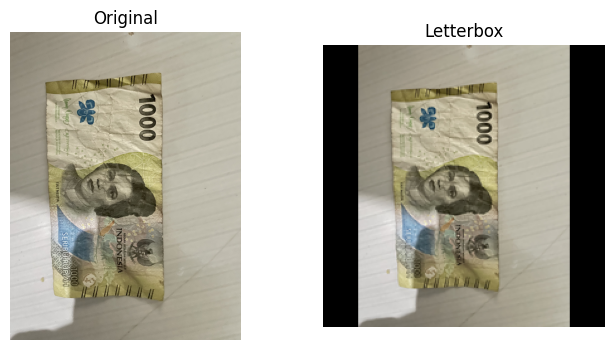

In [ ]:
# Contoh
image_path = "/content/drive/MyDrive/Dataset-Tambahan-Bersih/1000/IMG_2492.jpg"

img = Image.open(image_path).convert("RGB")

letterbox = Letterbox((224, 224))
img_letterbox = letterbox(img)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_letterbox)
plt.title("Letterbox")
plt.axis("off")

plt.show()

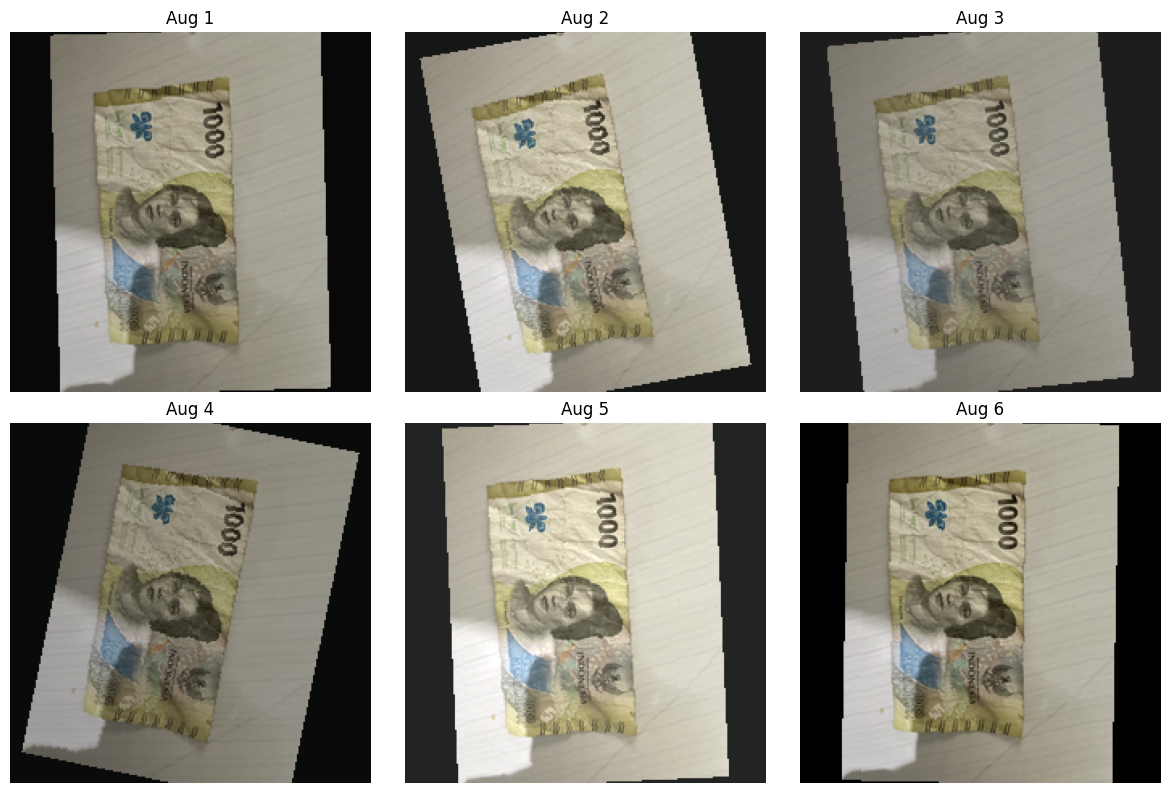

In [ ]:
img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(12,8))
for i in range(6):
    aug_tensor = train_transform(img)
    aug_img = aug_tensor.permute(1,2,0).numpy()
    mean = [0.485,0.456,0.406]
    std = [0.229,0.224,0.225]

    aug_img = aug_img * std + mean
    aug_img = aug_img.clip(0,1)

    plt.subplot(2,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
    plt.title(f"Aug {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

print(train_dataset.classes)
print("Jumlah kelas:", len(train_dataset.classes))

['1000', '10000', '100000', '2000', '20000', '5000', '50000', 'Bukan_Uang']
Jumlah kelas: 8


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Model
Model = MobileNetV2

In [ ]:
model = mobilenet_v2(
    weights=MobileNet_V2_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 133MB/s]


In [ ]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [ ]:
num_classes = 8

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

In [ ]:
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [ ]:
print(train_dataset.classes)
print(len(train_dataset.classes))

['1000', '10000', '100000', '2000', '20000', '5000', '50000', 'Bukan_Uang']
8


## Training

In [ ]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/15] Loss: 116.2278 Train Acc: 52.03%
Epoch [2/15] Loss: 76.5327 Train Acc: 78.54%
Epoch [3/15] Loss: 58.3418 Train Acc: 84.31%
Epoch [4/15] Loss: 49.5229 Train Acc: 85.62%
Epoch [5/15] Loss: 43.5346 Train Acc: 86.79%
Epoch [6/15] Loss: 39.3006 Train Acc: 87.87%
Epoch [7/15] Loss: 35.2318 Train Acc: 88.95%
Epoch [8/15] Loss: 33.9860 Train Acc: 88.32%
Epoch [9/15] Loss: 31.5743 Train Acc: 89.36%
Epoch [10/15] Loss: 30.9088 Train Acc: 89.40%
Epoch [11/15] Loss: 28.6161 Train Acc: 89.63%
Epoch [12/15] Loss: 26.8734 Train Acc: 90.40%
Epoch [13/15] Loss: 26.2376 Train Acc: 90.22%
Epoch [14/15] Loss: 25.8066 Train Acc: 90.35%
Epoch [15/15] Loss: 23.3263 Train Acc: 91.25%


In [ ]:
model.eval()

val_correct = 0
val_total = 0
val_loss = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_acc = 100 * val_correct / val_total

print(
    f"Val Loss: {val_loss:.4f} "
    f"Val Acc: {val_acc:.2f}%"
)

Val Loss: 5.1349 Val Acc: 93.19%


## Testing

In [ ]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 92.99%


# Evaluasi

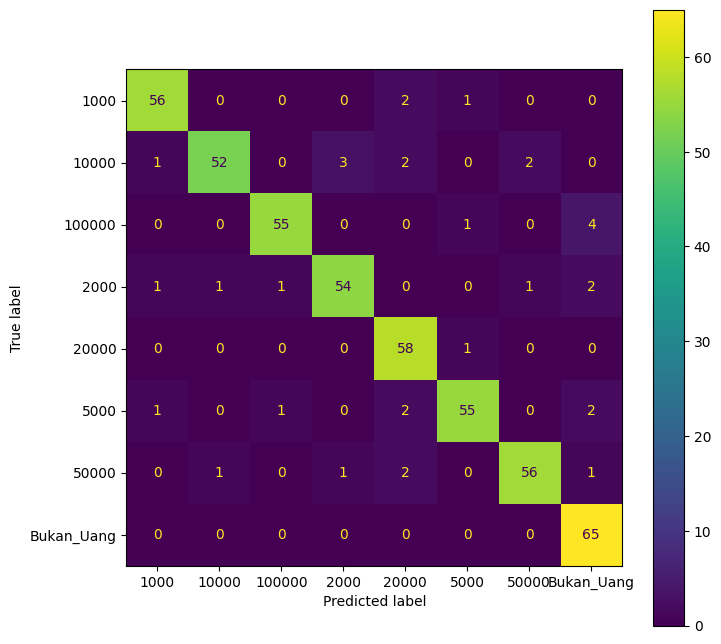

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)
plt.show()

In [ ]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=test_dataset.classes
    )
)

              precision    recall  f1-score   support

        1000       0.95      0.95      0.95        59
       10000       0.96      0.87      0.91        60
      100000       0.96      0.92      0.94        60
        2000       0.93      0.90      0.92        60
       20000       0.88      0.98      0.93        59
        5000       0.95      0.90      0.92        61
       50000       0.95      0.92      0.93        61
  Bukan_Uang       0.88      1.00      0.94        65

    accuracy                           0.93       485
   macro avg       0.93      0.93      0.93       485
weighted avg       0.93      0.93      0.93       485



# Save Model

In [ ]:
#Save Model
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/mobilenetv2_rupiahvision.pth"
)

In [ ]:
print(train_dataset.classes)

['1000', '10000', '100000', '2000', '20000', '5000', '50000', 'Bukan_Uang']


In [ ]:
classes = [
    '1000',
    '10000',
    '100000',
    '2000',
    '20000',
    '5000',
    '50000',
    'Bukan_Uang'
]

In [ ]:
with open(
    "/content/drive/MyDrive/classes.json",
    "w"
) as f:
    json.dump(classes, f)

In [ ]:
dummy = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy,
    "/content/drive/MyDrive/rupiahvision_mobilenet2.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

W0602 16:01:52.118000 459 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.11.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,8]>
            ),
            initializers=(
                %"features.0.0.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"features.1.conv.0.0.weight"<FLOAT,[32,1,3,3]>{Tensor(...)},
                %"features.1.conv.1.weight"<FLOAT,[16,32,1,1]>{Tensor(...)},
                %"features.2.conv.1.0.weight"<FLOAT,[96,1,3,3]>{Tensor(...)},
                %"classifier.1.bias"<FLOAT,[8]>{TorchTensor<FLOAT,[8]>(Parameter containing: tensor([-0.0149, -0.0475, -0.0221, -0.0414, -0.0276, -0.0119,  0.0219,  0.0985], device='cuda:0', requires_grad=True), name='cla

In [ ]:
!pip install -q onnx2tf
!pip install -q tensorflow
!pip install -q tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 

In [ ]:
!onnx2tf \
-i /content/drive/MyDrive/rupiahvision_mobilenet2.onnx \
-o /content/drive/MyDrive/rupiahvision_tf


Model optimizing started ============================================================
Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 10             │ 10               │
│ Clip       │ 35             │ 35               │
│ Constant   │ 110            │ 110              │
│ Conv       │ 52             │ 52               │
│ Gemm       │ 1              │ 1                │
│ ReduceMean │ 1              │ 1                │
│ Reshape    │ 1              │ 1                │
│ Model Size │ 8.7MiB         │ 8.5MiB           │
└────────────┴────────────────┴──────────────────┘

Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 10             │ 10               │
│ 

# Interpretasi

Model klasifikasi uang Rupiah berbasis transfer learning MobileNetV2 berhasil mencapai akurasi training sebesar 91,25%, validation sebesar 93,19%, dan testing sebesar 92,99%.

Hasil tersebut menunjukkan bahwa model mampu mempelajari pola pada dataset dengan sangat baik dan tetap mempertahankan performa yang tinggi pada data validasi maupun pengujian. Meskipun terdapat selisih antara akurasi training dan akurasi validation/testing yang mengindikasikan adanya kecenderungan overfitting, perbedaan tersebut masih dalam batas yang dapat diterima.

Secara keseluruhan, model memiliki kemampuan generalisasi yang baik dan mampu mengklasifikasikan nominal uang Rupiah dengan tingkat akurasi yang tinggi pada data yang belum pernah dilihat sebelumnya.

# Real Word Test

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Model MobileNetV2/mobilenetv2_rupiahvision.pth"

checkpoint = torch.load(MODEL_PATH, map_location="cpu")

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nKeys:")
    print(checkpoint.keys())

<class 'collections.OrderedDict'>

Keys:
odict_keys(['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.conv.0.0.weight', 'features.1.conv.0.1.weight', 'features.1.conv.0.1.bias', 'features.1.conv.0.1.running_mean', 'features.1.conv.0.1.running_var', 'features.1.conv.0.1.num_batches_tracked', 'features.1.conv.1.weight', 'features.1.conv.2.weight', 'features.1.conv.2.bias', 'features.1.conv.2.running_mean', 'features.1.conv.2.running_var', 'features.1.conv.2.num_batches_tracked', 'features.2.conv.0.0.weight', 'features.2.conv.0.1.weight', 'features.2.conv.0.1.bias', 'features.2.conv.0.1.running_mean', 'features.2.conv.0.1.running_var', 'features.2.conv.0.1.num_batches_tracked', 'features.2.conv.1.0.weight', 'features.2.conv.1.1.weight', 'features.2.conv.1.1.bias', 'features.2.conv.1.1.running_mean', 'features.2.conv.1.1.running_var', 'features.2.conv.1.1.num_batches_t

In [ ]:
with open("/content/drive/MyDrive/Model MobileNetV2/classes.json", "r") as f:
    classes = json.load(f)

print(classes)

['1000', '10000', '100000', '2000', '20000', '5000', '50000', 'Bukan_Uang']


In [ ]:
 DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = [
    '1000',
    '10000',
    '100000',
    '2000',
    '20000',
    '5000',
    '50000',
    'Bukan_Uang'
]

model = mobilenet_v2(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(classes)
)

MODEL_PATH = "/content/drive/MyDrive/Model MobileNetV2/mobilenetv2_rupiahvision.pth"

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE)
)

model = model.to(DEVICE)
model.eval()

print("Model berhasil dimuat")

Model berhasil dimuat


In [ ]:
REALWORLD_DIR = "/content/drive/MyDrive/Capstone Project - PJK-GU105/Test_Real_World_Images_Clean_JPG"

class Letterbox:
    def __init__(self, size=(224,224), fill=(0,0,0)):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        target_w, target_h = self.size
        w, h = img.size
        scale = min(target_w / w, target_h / h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
        canvas = Image.new("RGB", self.size, self.fill)
        paste_x = (target_w - new_w) // 2
        paste_y = (target_h - new_h) // 2
        canvas.paste(img, (paste_x, paste_y))
        return canvas

realworld_transform = transforms.Compose([
    Letterbox((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

realworld_dataset = ImageFolder(
    REALWORLD_DIR,
    transform=realworld_transform
)

realworld_loader = DataLoader(
    realworld_dataset,
    batch_size=32,
    shuffle=False
)

print("Jumlah gambar:", len(realworld_dataset))
print("Class:", realworld_dataset.classes)

Jumlah gambar: 259
Class: ['1000', '10000', '100000', '2000', '20000', '5000', '50000', 'Bukan_Uang']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in realworld_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)

print("="*50)
print(f"REAL WORLD ACCURACY : {acc*100:.2f}%")
print("="*50)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=realworld_dataset.classes
    )
)

REAL WORLD ACCURACY : 48.65%
              precision    recall  f1-score   support

        1000       0.43      0.10      0.16        30
       10000       0.67      0.06      0.11        35
      100000       1.00      0.33      0.50        30
        2000       0.20      0.58      0.30        31
       20000       0.47      0.84      0.60        31
        5000       0.71      0.39      0.50        31
       50000       0.71      0.52      0.60        29
  Bukan_Uang       0.73      0.95      0.82        42

    accuracy                           0.49       259
   macro avg       0.61      0.47      0.45       259
weighted avg       0.62      0.49      0.46       259



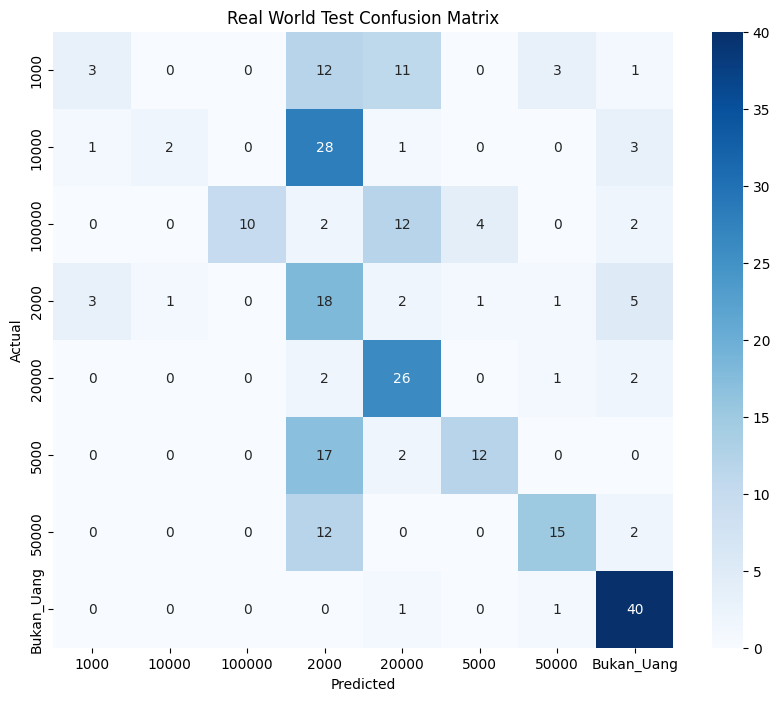

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=realworld_dataset.classes,
    yticklabels=realworld_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Real World Test Confusion Matrix")

plt.show()

Berdasarkan pengujian menggunakan Real World Test Set yang terdiri dari **259 gambar** dengan variasi kondisi nyata, seperti **perbedaan pencahayaan, sudut pengambilan gambar, jarak kamera, serta kondisi fisik uang yang beragam**, **model MobileNetV2** memperoleh **akurasi** sebesar **48,65%**. Hasil ini menunjukkan bahwa performa model pada kondisi penggunaan nyata masih lebih rendah dibandingkan pada data pengujian internal, sehingga kemampuan generalisasi model terhadap data di luar distribusi pelatihan **masih perlu ditingkatkan**.

Berdasarkan hasil evaluasi dan confusion matrix, model cenderung mengklasifikasikan beberapa nominal uang ke kelas Rp2.000 dan Rp20.000. **Kesalahan klasifikasi paling banyak** terjadi pada nominal **Rp1.000, Rp5.000, dan Rp10.000**, yang sebagian besar diprediksi sebagai Rp2.000. Selain itu, nominal **Rp10.000** memiliki performa yang **sangat rendah** dengan nilai **recall sebesar 0,06**, menunjukkan bahwa sebagian besar gambar Rp10.000 tidak berhasil dikenali dengan benar oleh model. Sebaliknya, nominal** Rp20.000** menunjukkan **performa terbaik** di antara kelas uang dengan nilai **recall sebesar 0,84**, sedangkan kelas **Bukan_Uang** memiliki **performa yang sangat baik** dengan nilai **recall mencapai 0,95**, yang menunjukkan bahwa **model mampu membedakan objek uang dan non-uang secara konsisten**.

Hasil pengujian ini menunjukkan bahwa **model telah memiliki kemampuan dasar dalam mengenali beberapa nominal uang rupiah dan membedakannya dari objek non-uang**. Namun, masih terdapat kesulitan dalam membedakan nominal yang memiliki karakteristik visual yang serupa. Oleh karena itu, diperlukan penambahan data pelatihan yang lebih beragam, khususnya untuk nominal yang memiliki tingkat kesalahan tinggi, serta proses fine-tuning lanjutan agar performa klasifikasi pada kondisi nyata dapat meningkat dan lebih siap untuk diterapkan pada aplikasi penggunaan sehari-hari.